IMPORTANT! Before beginning any lab assignment, be sure to **make your own copy** of the notebook and name it "lastname - Lab 3" or something similar.

# Lab 3: Advanced Predictive Analytics in Python (Part 1)

## Objective

For this lab, I want you to continue exploring using Jupyter notebooks to execute Python programs, partly because it avoids the need to have to install many Python packages on your computer. We'll also take the opportunity to have you use some of the data handling techniques we have introduce in class (and Chapter 3 of the textbook) for a Business problem... addressing  player churn in online gaming.

## Google Colab Specific Instructions

*Google Colab* is a free online Jupyter notebook environment that allows you to run Python code in your web browser without any setup. It comes with many popular libraries pre-installed, making it a convenient choice for data analysis and machine learning tasks.  However, it doesn't currently support the `polars` library natively, so we will need to install it manually.

To 'execute' a cell in Jupyter, you can either click the play button on the left side of the cell or press `Shift + Enter` on your keyboard.  So click on the first cell below and execute it to install the required libraries.

In [ ]:
# DO NOT RUN THIS CELL UNLESS YOU ARE IN GOOGLE COLAB
#
# Execute this cell to set up the notebook environment, this is actually
# only needed if you are running this notebook in Google Colab.  It installs
# the required packages using the command line interface to the linux
# backend that Colab uses.
!pip install polars imbalanced-learn

## Scenario: Player Churn in Online Gaming 🎮

### Background
You are a **data analyst at a major online gaming platform** that offers subscription-based access to multiple multiplayer games. Recently, the company has noticed a **decline in active subscriptions**, and your team has been tasked with **analyzing player churn** to identify trends and recommend strategies to improve player retention.

**Your goal:** Explore player data, identify patterns, and suggest solutions to reduce churn.

---

## **Part 1: Business Understanding**
### **Discussion Questions**
1. What are some **reasons players might stop subscribing** to an online gaming service?
2. What are the **potential business impacts** of high churn rates?
3. What **key data points** might help predict whether a player will churn?

Write your answers below:

```markdown
# 1. Double-click here (in the black surrounding space)
# 2. Add your answers!
# 3. Keep them inside the markdown quotes.
```

## **Part 2: Data Understanding**
### **Step 1: Load the Dataset** 📂
We will use a dataset (`gaming_churn_data.csv`) that contains the following fields:

- `PlayerID` - Unique identifier for each player
- `Age` - Player's age
- `SubscriptionLength` - Length of active subscription (in months)
- `PlayTimePerWeek` - Average playtime per week (hours)
- `InGamePurchases` - Total in-game purchases made ($)
- `CustomerSupportCalls` - Number of support interactions
- `Churn` - Whether the player has churned (Yes/No)

You'll find it here (download as a .CSV) or on D2L; upload it to the environment here through the files tab on the left.

Link: https://docs.google.com/spreadsheets/d/1tArkAJHjuLUvWAxGz3oyamk25gaXbqsI5BWk6PS0Uvs/edit?usp=sharing

In [ ]:
# Run this code block
import pandas as pd

# Load dataset
df = pd.read_csv("gaming_churn_data.csv")

# Display first few rows - call df and use the head() method


,PlayerID,Age,SubscriptionLength,PlayTimePerWeek,InGamePurchases,CustomerSupportCalls,Churn
0,1,22,12,8.5,15.3,0,No
1,2,35,24,20.1,50.5,1,Yes
2,3,28,6,5.2,10.0,2,No
3,4,40,18,12.8,75.2,1,No
4,5,21,8,6.9,5.0,0,Yes


### **Step 2: Check for Missing Values** 🔍

In [ ]:
# Check for missing values
# Call the dataset with df, and chain it with the methods isnull() and sum() in one line


,0
PlayerID,0
Age,0
SubscriptionLength,0
PlayTimePerWeek,0
InGamePurchases,0
CustomerSupportCalls,0
Churn,0


*Question:* If missing values exist, how should they be handled?


```markdown
# Put your answer here (same as before)
```

## **Part 3: Exploratory Data Analysis (EDA)**



### **Step 3: Visualizing Key Metrics** 📊
#### **1. Distribution of Subscription Lengths**

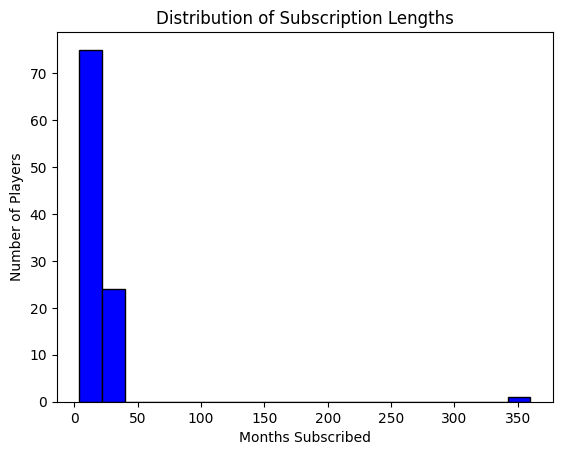

In [ ]:
# import the matplotlib.pyplot library as plt

# Create a histogram of subscription length using the hist() method with 20 bins
# Make it blue with black edges

# Title it "Distribution of Subscription Lengths"

# Call the xlabel "Months Subscribed"

# Call the ylabel "Number of Players"

# Display the plot with plt.show()


#### **2. Relationship Between In-Game Purchases and Churn**


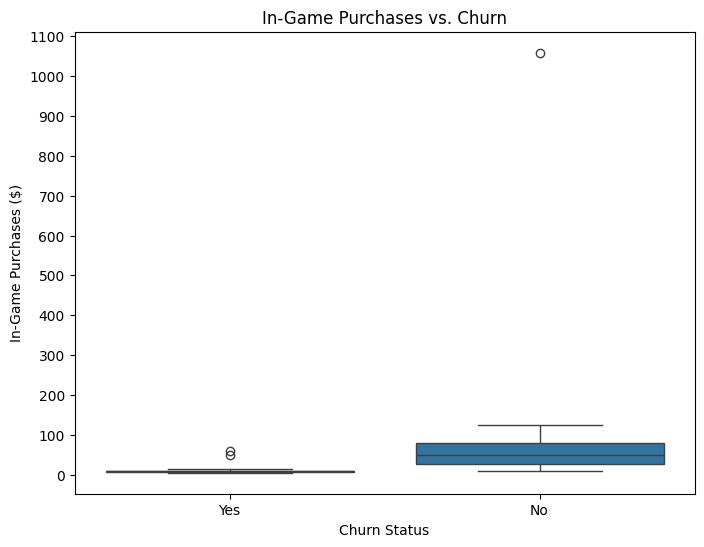

In [ ]:
# All of this code is written for you
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Sort data by median in-game purchases for better visualization
order = df.groupby("Churn")["InGamePurchases"].median().sort_values().index

plt.figure(figsize=(8, 6))
sns.boxplot(x=df["Churn"], y=df["InGamePurchases"], order=order) # Experiment with the palette and hue parameters to visualize even more relationships!
plt.title("In-Game Purchases vs. Churn")
plt.gca().yaxis.set_major_locator(mtick.MultipleLocator(100))  # Set y-axis increments to $100
plt.ylabel("In-Game Purchases ($)")
plt.xlabel("Churn Status")
plt.show()

*Question:* What does the box plot suggest about churn and in-game purchases?


```markdown
# Put your answer here (same as before)
```

## **Part 4: Identifying Data Quality Issues** ⚠️
### **Step 4: Detecting Outliers**

Our box plot also showed us that we might have a couple of outliers hanging around. Let's find them!

In [ ]:
# Code to find outliers in PlayTimePerWeek has been added for you
Q1 = df["PlayTimePerWeek"].quantile(0.25)
Q3 = df["PlayTimePerWeek"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["PlayTimePerWeek"] < lower_bound) | (df["PlayTimePerWeek"] > upper_bound)]
print("Potential Outliers:")
print(outliers)

# Add your own code to find outliers in Age, SubscriptionLength, and InGamePurchases


Potential Outliers:
   PlayerID  Age  SubscriptionLength  PlayTimePerWeek  InGamePurchases  \
7         8   19                   5             75.0             12.0   

   CustomerSupportCalls Churn  
7                     0   Yes  


*Question:* Based on the output, should outliers be removed or transformed? Why?


```markdown
# Put your answer here (same as before)
```

## **Part 5: Business Insights & Next Steps**
### **Step 5: Key Takeaways** 📌

1. What trends did you notice in player behavior that might be linked to churn?
2. Based on your findings, what recommendations would you make to **reduce churn** in the gaming industry?

Write your thoughts below:

```markdown
# Put your answers here (same as before)
```

## Deliverables
*Options*

 * **Colab link**: Make sure to update the share settings, and submit a link to your Colab Notebook to the D2L dropbox. YOU WILL NEED TO SUBMIT SOMETHING WITH IT, so just submit a blank text file or something.
 * **.ipynb file**: Download the Jupyter notebook file from Colab or wherever you're working on it and submit that to D2L.
 * **PDF**: A PDF is fine if you want to take screenshots and answer in a Word doc; just be sure to save as a PDF, not a .docx file, before you submit.

 You only need to submit **one of these things**!!!